In [223]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [224]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

In [225]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [226]:
test.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


In [227]:
train.shape

(1460, 81)

In [228]:
test.shape

(1459, 80)

In [229]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [230]:
test.info()

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   str    
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   str    
 6   Alley          107 non-null    str    
 7   LotShape       1459 non-null   str    
 8   LandContour    1459 non-null   str    
 9   Utilities      1457 non-null   str    
 10  LotConfig      1459 non-null   str    
 11  LandSlope      1459 non-null   str    
 12  Neighborhood   1459 non-null   str    
 13  Condition1     1459 non-null   str    
 14  Condition2     1459 non-null   str    
 15  BldgType       1459 non-null   str    
 16  HouseStyle     1459 non-null   str    
 17  OverallQual    1459 non-null   int64  
 18  OverallCond    1459

In [231]:
train.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [232]:
test.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold
count,1459.000000,1459.000000,1232.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1444.000000,1458.000000,...,1458.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,2190.000000,57.378341,68.580357,9819.161069,6.078821,5.553804,1971.357779,1983.662783,100.709141,439.203704,...,472.768861,93.174777,48.313914,24.243317,1.794380,17.064428,1.744345,58.167923,6.104181,2007.769705
std,421.321334,42.746880,22.376841,4955.517327,1.436812,1.113740,30.390071,21.130467,177.625900,455.268042,...,217.048611,127.744882,68.883364,67.227765,20.207842,56.609763,30.491646,630.806978,2.722432,1.301740
min,1461.000000,20.000000,21.000000,1470.000000,1.000000,1.000000,1879.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000
25%,1825.500000,20.000000,58.000000,7391.000000,5.000000,5.000000,1953.000000,1963.000000,0.000000,0.000000,...,318.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,2007.000000
50%,2190.000000,50.000000,67.000000,9399.000000,6.000000,5.000000,1973.000000,1992.000000,0.000000,350.500000,...,480.000000,0.000000,28.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000
75%,2554.500000,70.000000,80.000000,11517.500000,7.000000,6.000000,2001.000000,2004.000000,164.000000,753.500000,...,576.000000,168.000000,72.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000
max,2919.000000,190.000000,200.000000,56600.000000,10.000000,9.000000,2010.000000,2010.000000,1290.000000,4010.000000,...,1488.000000,1424.000000,742.000000,1012.000000,360.000000,576.000000,800.000000,17000.000000,12.000000,2010.000000


In [233]:
train.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [234]:
test.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           4
LotFrontage      227
LotArea            0
                ... 
MiscVal            0
MoSold             0
YrSold             0
SaleType           1
SaleCondition      0
Length: 80, dtype: int64

In [235]:
train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [236]:
train.SalePrice.describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

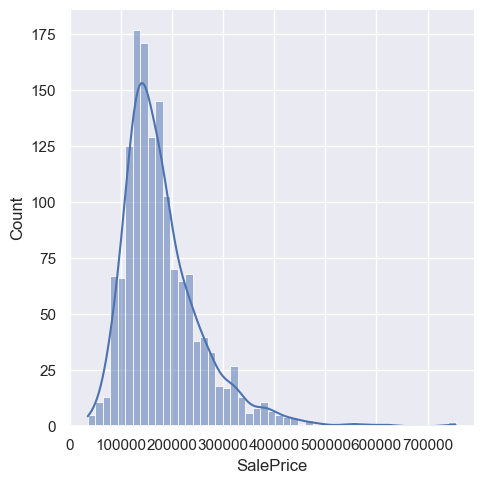

In [237]:
sns.displot(train['SalePrice'], kde=True)

In [238]:
# Skewness and Kurtosis
print("Skewness : %f" % train['SalePrice'].skew())
print("Kurtosis : %f" % train['SalePrice'].kurt())

Skewness : 1.882876
Kurtosis : 6.536282


In [239]:
target = np.log(train.SalePrice)
print("Skewness : %f" % target.skew())
print("Kurtosis : %f" % target.kurt())

Skewness : 0.121335
Kurtosis : 0.809532


In [240]:
numeric_features = train.select_dtypes(include=[np.number])
numeric_features.dtypes

Id                 int64
MSSubClass         int64
LotFrontage      float64
LotArea            int64
OverallQual        int64
OverallCond        int64
YearBuilt          int64
YearRemodAdd       int64
MasVnrArea       float64
BsmtFinSF1         int64
BsmtFinSF2         int64
BsmtUnfSF          int64
TotalBsmtSF        int64
1stFlrSF           int64
2ndFlrSF           int64
LowQualFinSF       int64
GrLivArea          int64
BsmtFullBath       int64
BsmtHalfBath       int64
FullBath           int64
HalfBath           int64
BedroomAbvGr       int64
KitchenAbvGr       int64
TotRmsAbvGrd       int64
Fireplaces         int64
GarageYrBlt      float64
GarageCars         int64
GarageArea         int64
WoodDeckSF         int64
OpenPorchSF        int64
EnclosedPorch      int64
3SsnPorch          int64
ScreenPorch        int64
PoolArea           int64
MiscVal            int64
MoSold             int64
YrSold             int64
SalePrice          int64
dtype: object

In [241]:
object_features = train.select_dtypes(exclude=[np.number])
object_features.dtypes

MSZoning         str
Street           str
Alley            str
LotShape         str
LandContour      str
Utilities        str
LotConfig        str
LandSlope        str
Neighborhood     str
Condition1       str
Condition2       str
BldgType         str
HouseStyle       str
RoofStyle        str
RoofMatl         str
Exterior1st      str
Exterior2nd      str
MasVnrType       str
ExterQual        str
ExterCond        str
Foundation       str
BsmtQual         str
BsmtCond         str
BsmtExposure     str
BsmtFinType1     str
BsmtFinType2     str
Heating          str
HeatingQC        str
CentralAir       str
Electrical       str
KitchenQual      str
Functional       str
FireplaceQu      str
GarageType       str
GarageFinish     str
GarageQual       str
GarageCond       str
PavedDrive       str
PoolQC           str
Fence            str
MiscFeature      str
SaleType         str
SaleCondition    str
dtype: object

In [242]:
corr = numeric_features.corr()

print(corr['SalePrice'].sort_values(ascending=False)[:5], '\n')
print(corr['SalePrice'].sort_values(ascending=False)[-5:])

SalePrice      1.000000
OverallQual    0.790982
GrLivArea      0.708624
GarageCars     0.640409
GarageArea     0.623431
Name: SalePrice, dtype: float64 

YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


c:\Users\Venkatesh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\seaborn\matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)


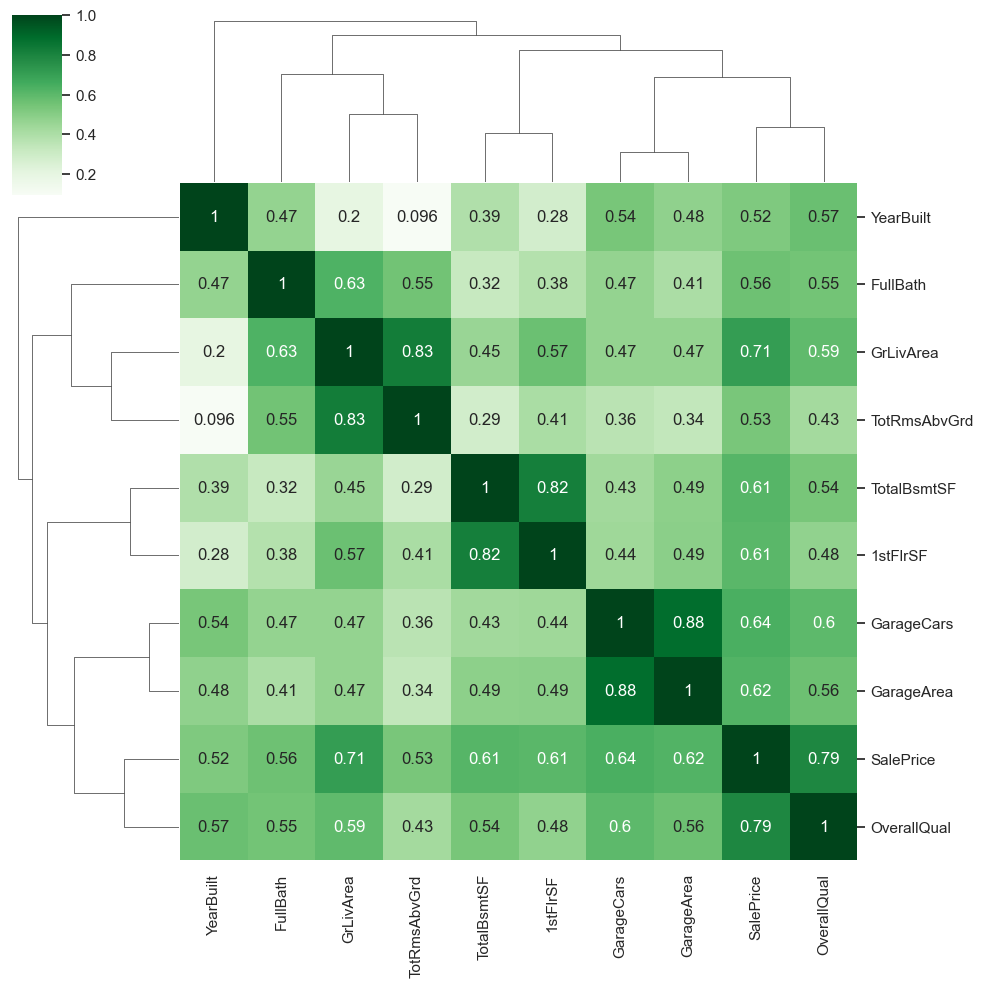

In [243]:
#'SalePrice' Correlation Matrix

k = 10
cols = corr.nlargest(k, 'SalePrice')['SalePrice'].index 
cm = np.corrcoef(train[cols].values.T)
sns.set(font_scale = 1.00)
hm = sns.clustermap(cm, annot = True, cmap='Greens', cbar= 'True', square = True, yticklabels=cols.values, xticklabels=cols.values)

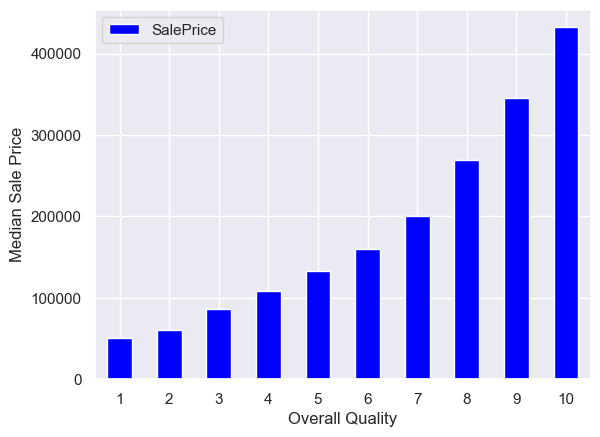

In [244]:
quality_pivot = train.pivot_table(index='OverallQual', values='SalePrice', aggfunc=np.median)
quality_pivot.plot(kind='bar', color='blue')
plt.xlabel('Overall Quality')
plt.ylabel('Median Sale Price')
plt.xticks(rotation=0)
plt.show()

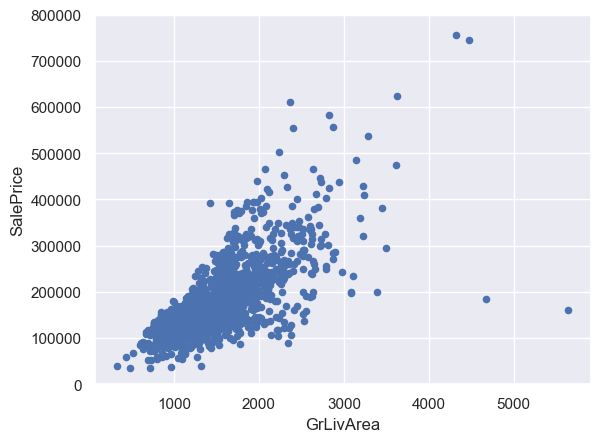

In [245]:
#Analyse SalePrice/GrLiveArea 
data = pd.concat([train['SalePrice'], train['GrLivArea']], axis=1)
data.plot.scatter(x='GrLivArea', y='SalePrice', ylim=(0, 800000));

## Outliers

In [246]:
train = train[train['GarageArea'] < 1200]

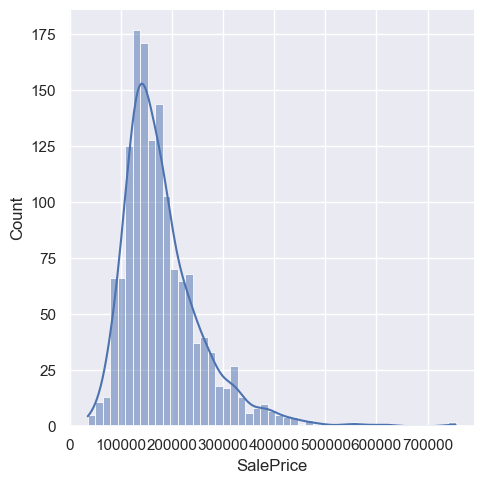

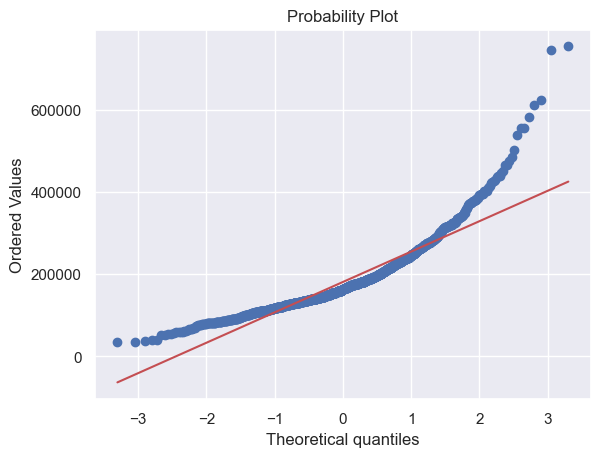

In [247]:
# Histogram and normal probability plot
from scipy import stats
from scipy.stats import norm 
from sklearn.preprocessing import StandardScaler
sns.displot(train['SalePrice'],  kde=True)
fig = plt.figure()
res = stats.probplot(train['SalePrice'], plot=plt)

In [248]:
train['Total_Bathrooms'] = (train['FullBath']+(0.5*train['HalfBath'])+train['BsmtFullBath']+(0.5*train['BsmtHalfBath']))
test['Total_Bathrooms'] = (test['FullBath']+(0.5*test['HalfBath'])+test['BsmtFullBath']+(0.5*test['BsmtHalfBath']))

train['totalSF'] = (train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF'])
test['TotalSF'] = (test['TotalBsmtSF'] + test['1stFlrSF'] + test['2ndFlrSF'])

In [249]:
train = train.drop(['FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath'], axis=1)
test = test.drop(['FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath'], axis=1)

train = train.drop(['TotalBsmtSF', '1stFlrSF', '2ndFlrSF'], axis=1)
test = test.drop(['TotalBsmtSF', '1stFlrSF', '2ndFlrSF'], axis=1)

In [250]:
# Missing Data

total = train.isnull().sum().sort_values(ascending=False)
percent = (train.isnull().sum()/train.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(20)

,Total,Percent
PoolQC,1449,0.995876
MiscFeature,1402,0.963574
Alley,1364,0.937457
Fence,1174,0.806873
MasVnrType,871,0.598625
FireplaceQu,689,0.473540
LotFrontage,258,0.177320
GarageFinish,81,0.055670
GarageQual,81,0.055670
GarageType,81,0.055670


## non-numeric features

In [251]:
categoricals = train.select_dtypes(exclude=[np.number])
categoricals.describe()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1455,1455,91,1455,1455,1455,1455,1455,1455,1455,...,1374,1374,1374,1374,1455,6,281,53,1455,1455
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
freq,1147,1450,50,921,1309,1454,1048,1378,225,1257,...,867,605,1306,1321,1335,2,157,48,1266,1196


In [252]:
cate = test.select_dtypes(exclude=[np.number])
cate.describe()

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1455,1459,107,1459,1459,1457,1459,1459,1459,1459,...,1383,1381,1381,1381,1459,3,290,51,1458,1459
unique,5,2,2,4,4,1,5,3,25,9,...,6,3,4,5,3,2,4,3,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Ex,MnPrv,Shed,WD,Normal
freq,1114,1453,70,934,1311,1457,1081,1396,218,1251,...,853,625,1293,1328,1301,2,172,46,1258,1204


In [253]:
train['Bsmt'] = (train['BsmtQual'] + train['BsmtCond'])
test['Bsmt'] = (test['BsmtQual'] + test['BsmtCond'])

train['Garage'] = (train['GarageQual'] + train['GarageCond'])
test['Garage'] = (test['GarageQual'] + test['GarageCond'])

train['External'] = (train['ExterQual'] + train['ExterCond'])
test['External'] = (test['ExterQual'] + test['ExterCond'])

In [254]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder 

cols = ('FireplaceQu', 'Bsmt', 'Garage', 'External', 
        'KitchenQual', 'Functional', 'Fence', 'BsmtExposure', 
        'GarageFinish', 'LandSlope','PavedDrive', 'Street', 
        'Alley', 'CentralAir', 'MSSubClass', 'OverallCond', 
        'YrSold', 'YearRemodAdd')

# process columns, apply LabelEncoder to categorical features
for c in cols:
    lbl = LabelEncoder()
    lbl.fit(list(train[c].values))
    train[c] = lbl.transform(list(train[c].values))
    lbl.fit(list(test[c].values))
    test[c] = lbl.transform(list(test[c].values))

In [255]:
data = train.select_dtypes(include=[np.number]).interpolate().dropna()
test = test.select_dtypes(include=[np.number]).interpolate().dropna()

In [256]:
X = data.drop(['SalePrice', 'Id'], axis=1)
y = np.log(train.SalePrice)

In [257]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [258]:
from sklearn import linear_model 
from sklearn.metrics import r2_score 
from sklearn.metrics import mean_squared_error 

# Create linear regression object 
regr = linear_model.LinearRegression()

# Train the model using the training sets
regr.fit(X_train, y_train)

# Make predictions using the testing sets
y_pred = regr.predict(X_test)
print("The accuracy of Linear Regression is", r2_score(y_test, y_pred))
print("RMSE is: \n", mean_squared_error(y_test, y_pred))

The accuracy of Linear Regression is 0.8940439876798243
RMSE is: 
 0.015716378275705163


In [259]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [260]:
import xgboost as xgb

xg_reg = xgb.XGBRegressor(learning_rate=0.01, n_estimators=3460,
                          max_depth=3, min_child_weight=0, gamma=0,
                          subsample=0.7, colsample_bytree=0.7,
                          objective= 'reg:linear', nthread=4,
                          scale_pos_weight=1, seed=27, reg_alpha=0.00006)
xg_reg.fit(X_train, y_train)

preds = xg_reg.predict(X_test)

print('The accuracy of the xgboost is', r2_score(y_test, preds))
print('RMSE is: \n', mean_squared_error(y_test, preds))

c:\Users\Venkatesh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [22:08:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


The accuracy of the xgboost is 0.9080153182801052
RMSE is: 
 0.013644020965150376


In [261]:
from sklearn.model_selection import KFold 
n_splits_val=3
kfolds = KFold(n_splits=n_splits_val, shuffle=False)

In [262]:
from sklearn.ensemble import GradientBoostingRegressor 

gbr_model = GradientBoostingRegressor(n_estimators=3460, learning_rate=0.01,
                                      max_depth=3, max_features='sqrt',
                                      min_samples_leaf=15, min_samples_split=10,
                                      loss='huber', random_state=5)

gbr_model.fit(X_train, y_train)
gbr_preds = gbr_model.predict(X_test)
print('The accuracy of the Gradient boost is', r2_score(y_test, gbr_preds))
print('RMSE is: \n', mean_squared_error(y_test, gbr_preds))

The accuracy of the Gradient boost is 0.907268395226794
RMSE is: 
 0.01375481151862279


In [263]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [264]:
from lightgbm import LGBMRegressor
from sklearn.preprocessing import RobustScaler 
from sklearn.pipeline import make_pipeline 

lgbm_model = LGBMRegressor(objective='regression', num_leaves=5,
                          learning_rate=0.05, n_estimators=720,
                          max_bin=55, bagging_fraction=0.8,
                          bagging_freq = 5, feature_fraction=0.2319,
                          feature_fraction_seed=9, bagging_seed=9,
                          min_data_in_leaf=6, min_sum_hessian_in_leaf=11)
lgbm_model.fit(X_train, y_train)
lgbm_preds = lgbm_model.predict(X_test)
print('The accuracy of the lgbm Regressor is', r2_score(y_test, lgbm_preds))
print('RMSE is: \n', mean_squared_error(y_test, lgbm_preds))

[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11

In [265]:
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import RobustScaler 
from sklearn.pipeline import make_pipeline 

r_alphas = [.0001, .0003, .0005, .0007, .0009, .01, 0.05, 0.1, 0.3, 1]
ridge_model = make_pipeline(RobustScaler(), RidgeCV(alphas=r_alphas, cv=kfolds))
ridge_model.fit(X_train, y_train)

ridge_preds = ridge_model.predict(X_test)
print('The accuracy of the ridgee Regressor is', r2_score(y_test, ridge_preds))
print('RMSE is: \n', mean_squared_error(y_test, ridge_preds))

The accuracy of the ridgee Regressor is 0.8960959477872582
RMSE is: 
 0.015412012524777904


In [266]:
from sklearn.linear_model import LassoCV 

alphas2 = [1, 0.1, 0.001, 0.005]
lasso_model = make_pipeline(RobustScaler(),
                            LassoCV(max_iter=10000000,
                                    alphas=alphas2,
                                    random_state=42,
                                    cv = kfolds))
lasso_model.fit(X_train, y_train)
lasso_preds = lasso_model.predict(X_test)
print("The accuracy of the lasso Regressor is", r2_score(y_test, lasso_preds))
print('RMSE is: \n', mean_squared_error(y_test, lasso_preds))

The accuracy of the lasso Regressor is 0.8971729622027795
RMSE is: 
 0.015252259759530647


In [267]:
from sklearn.linear_model import ElasticNetCV

e_alphas = [0.0001, 0.0002, 0.0003, 0.0004, 0.0005, 0.0006, 0.0007]
e_l1ratio = [0.8, 0.85, 0.9, 0.95, 0.99, 1]

elastic_model = make_pipeline(RobustScaler(),
                              ElasticNetCV(max_iter=10000000, alphas=e_alphas,
                                           cv=kfolds, l1_ratio=e_l1ratio))

elastic_model.fit(X_train, y_train)
elastic_preds = elastic_model.predict(X_test)
print('The accuracy of the Elastic Net CV is', r2_score(y_test, elastic_preds))
print('RMSE is: \n', mean_squared_error(y_test, elastic_preds))

The accuracy of the Elastic Net CV is 0.896847661624595
RMSE is: 
 0.015300511357793947


In [268]:
pip install mlxtend

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [269]:
from mlxtend.regressor import StackingCVRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler 
#setup models
# ridge = make_pipeline(RobustScaler(),
#                       RidgeCV(alphas = r_alphas))

lasso = make_pipeline(RobustScaler(),
                      LassoCV(max_iter=10000000, alphas = alphas2, random_state=42))

elasticnet = make_pipeline(RobustScaler(),
                           ElasticNetCV(max_iter=10000000, alphas=e_alphas, l1_ratio=e_l1ratio))

lgbm_model = LGBMRegressor(objective='regression', num_leaves=5, learning_rate = 0.05, n_estimators=720,
                          max_bin = 55, bagging_fraction=0.8, bagging_freq = 5, feature_fraction=0.2319,
                          feature_fraction_seed=9, bagging_seed=9, min_data_in_leaf=6, min_sum_hessian_in_leaf=11)
lgbm_model.fit(X_train, y_train)

gbr_model = GradientBoostingRegressor()
gbr_model.fit(X_train, y_train)

#stack 
stack_gen = StackingCVRegressor(regressors=(#ridge,
                            lasso, elasticnet, gbr_model,
                            lgbm_model),
                            meta_regressor=gbr_model,
                            use_features_in_secondary=True)

stackX = np.array(X_train)
stacky = np.array(y_train)
stack_gen_model = stack_gen.fit(stackX, stacky)


[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11

c:\Users\Venkatesh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Venkatesh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11

c:\Users\Venkatesh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\Venkatesh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11

c:\Users\Venkatesh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11

In [270]:
em_preds = elastic_model.predict(X_test)
lasso_preds = lasso_model.predict(X_test)
#ridge_preds = ridge_model.predict(X_test)
stack_gen_pred = stack_gen_model.predict(X_test)
lgbm_preds = lgbm_model.predict(X_test)
gbr_preds = gbr_model.predict(X_test)

[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] min_data_in_leaf is set=6, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=6
[LightGBM] [Warning] feature_fraction is set=0.2319, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.2319
[LightGBM] [Warning] min_sum_hessian_in_leaf is set=11, min_child_weight=0.001 will be ignored. Current value: min_sum_hessian_in_leaf=11

c:\Users\Venkatesh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RobustScaler was fitted without feature names
  warnings.warn(
c:\Users\Venkatesh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RobustScaler was fitted without feature names
  warnings.warn(
c:\Users\Venkatesh\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but GradientBoostingRegressor was fitted without feature names
  warnings.warn(


In [271]:
print('RMSE is: \n', mean_squared_error(y_test, stack_gen_pred))

RMSE is: 
 0.014349039645530654


In [272]:
stack_preds_1 = ((0.1*em_preds) + (0.1*lasso_preds) + (0.4*gbr_preds) + (0.2*lgbm_preds) + (0.2*stack_gen_pred))
print('The accuracy of the stack Regressor is', r2_score(y_test, stack_preds_1))
print('RMSE is: \n', mean_squared_error(y_test, stack_preds_1))

The accuracy of the stack Regressor is 0.9107102603831344
RMSE is: 
 0.013244282162274848


In [273]:
feats = test.select_dtypes(include=[np.number]).interpolate().dropna()
# feats = test.drop([ 'Id'], axis=1)

In [274]:
em_preds = elastic_model.predict(feats)
lasso_preds = lasso_model.predict(feats)
#ridge_preds = ridge_model.predict(feats)
stack_gen_preds = stack_gen_model.predit(feats)
lgbm_preds = lgbm_model.predict(feats)
gbr_preds = gbr_model.predict(feats)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Id
- TotalSF
Feature names seen at fit time, yet now missing:
- totalSF


In [ ]:
stack_preds = ((0.01*em_preds) + (0.1*lasso_preds) + (0.4 * gbr_preds) + (0.2*lgbm_preds)+(0.2*stack_gen_preds))

NameError: name 'stack_gen_preds' is not defined

In [275]:
final_predictions = np.exp(stack_preds)
print("Original predictions are: \n", stack_preds[:5], "\n")
print("Final predictions are: \n", final_predictions[:5])

NameError: name 'stack_preds' is not defined

In [276]:
submission = pd.DataFrame()
submission['Id'] = test.Id 
submission['SalePrice'] = final_predictions
submission.to_csv('submission1.csv', index=False)

NameError: name 'final_predictions' is not defined